In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv('house_prce(withnone).csv')
df


,House_ID,Area_sqft,Bedrooms,Bathrooms,Age_years,Location,Garage,Floors,Distance_to_City_km,Price
0,H001,1200.0,3.0,2.0,10.0,Ludhiana,1.0,1.0,5.2,5200000.0
1,H002,1500.0,3.0,2.0,8.0,Chandigarh,1.0,2.0,7.1,7800000.0
2,H003,950.0,2.0,1.0,15.0,Amritsar,0.0,1.0,4.5,3500000.0
3,H004,1800.0,4.0,3.0,5.0,Mohali,1.0,2.0,8.3,9200000.0
4,H005,1100.0,2.0,2.0,12.0,Jalandhar,1.0,1.0,3.8,4100000.0
5,H006,2200.0,4.0,3.0,3.0,Chandigarh,1.0,2.0,6.4,11500000.0
6,H007,1350.0,3.0,NaN,9.0,Ludhiana,1.0,1.0,4.9,5700000.0
7,H008,1000.0,2.0,1.0,20.0,Amritsar,0.0,1.0,6.2,3100000.0
8,H009,1650.0,3.0,2.0,7.0,Mohali,1.0,2.0,9.1,8500000.0
9,H010,NaN,4.0,3.0,4.0,Chandigarh,1.0,2.0,5.7,10800000.0


In [4]:
df.shape


(50, 10)

In [8]:
df.columns

Index(['House_ID', 'Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_years',
       'Location', 'Garage', 'Floors', 'Distance_to_City_km', 'Price'],
      dtype='str')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   House_ID             50 non-null     str    
 1   Area_sqft            48 non-null     float64
 2   Bedrooms             48 non-null     float64
 3   Bathrooms            48 non-null     float64
 4   Age_years            48 non-null     float64
 5   Location             50 non-null     str    
 6   Garage               49 non-null     float64
 7   Floors               48 non-null     float64
 8   Distance_to_City_km  47 non-null     float64
 9   Price                49 non-null     float64
dtypes: float64(8), str(2)
memory usage: 4.0 KB


In [5]:
df.isnull().sum()

House_ID               0
Area_sqft              2
Bedrooms               2
Bathrooms              2
Age_years              2
Location               0
Garage                 1
Floors                 2
Distance_to_City_km    3
Price                  1
dtype: int64

In [6]:
miss_value=df.isnull().sum()/df.shape[0]*100
miss_value

House_ID               0.0
Area_sqft              4.0
Bedrooms               4.0
Bathrooms              4.0
Age_years              4.0
Location               0.0
Garage                 2.0
Floors                 4.0
Distance_to_City_km    6.0
Price                  2.0
dtype: float64

In [9]:
X = df[['Area_sqft', 'Bedrooms', 'Age_years']]
y = df['Price']

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 3)

In [12]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(40, 3)
(10, 3)
(40,)
(10,)


In [19]:
Area_sqft_median = X_train['Area_sqft'].median()
Bedrooms_median = X_train['Bedrooms'].median()
Age_years_median = X_train['Age_years'].median()

In [20]:
X_train['Area_sqft'] = X_train['Area_sqft'].fillna(Area_sqft_median)
X_train['Bedrooms'] = X_train['Bedrooms'].fillna(Bedrooms_median)
X_train['Age_years'] = X_train['Age_years'].fillna(Age_years_median)

In [21]:
X_test['Area_sqft'] = X_test['Area_sqft'].fillna(Area_sqft_median)
X_test['Bedrooms'] = X_test['Bedrooms'].fillna(Bedrooms_median)
X_test['Age_years'] = X_test['Age_years'].fillna(Age_years_median)

In [22]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())

Area_sqft    0
Bedrooms     0
Age_years    0
dtype: int64
Area_sqft    0
Bedrooms     0
Age_years    0
dtype: int64


In [23]:
model = LinearRegression()
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 7409.84,-93088.08,-64000.21]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Area_sqft','Bedrooms','Age_years']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.162e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [27]:
y_pred = model.predict(X_test)

new_y_pred = np.round(y_pred, 2)
result = pd.DataFrame({'Actual Price': y_test.values, 'Predicted Price': new_y_pred})
result.head(10)

,Actual Price,Predicted Price
0,2900000.0,2168371.44
1,11900000.0,11463514.16
2,10800000.0,6138527.68
3,9300000.0,9398857.20
4,5500000.0,5975614.94
5,4800000.0,5571417.32
6,10500000.0,11157022.38
7,4600000.0,5847614.53
8,NaN,7161189.31
9,5700000.0,5985713.13


In [28]:
print("Coefficients:", dict(zip(X.columns, model.coef_)))
print("Intercept:", model.intercept_)

Coefficients: {'Area_sqft': np.float64(7409.839826126474), 'Bedrooms': np.float64(-93088.08496199182), 'Age_years': np.float64(-64000.20621771193)}
Intercept: -3162304.5227244515


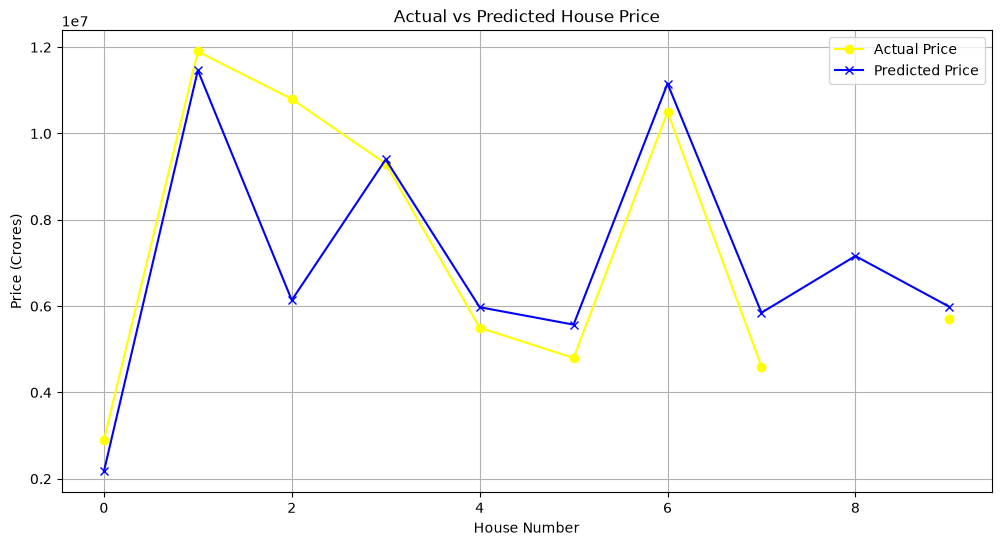

In [29]:
plt.figure(figsize=(12, 6))

plt.plot(y_test.values[:50], color='yellow', marker='o', label='Actual Price')
plt.plot(y_pred[:50], color='blue', marker='x', label='Predicted Price')

plt.xlabel('House Number')
plt.ylabel('Price (Crores)')
plt.title('Actual vs Predicted House Price')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
area = int(input("Enter the area of the house: "))
bedrooms = int(input("Enter the number of bedrooms: "))
Age_years = int(input("Enter the age of the house: "))

user_data = pd.DataFrame(
    [[area, bedrooms, Age_years]],
    columns=['Area_sqft', 'Bedrooms', 'Age_years']
)

predicted_price = model.predict(user_data)[0]

print("Model Predicted Price:", predicted_price)
print(f"Predicted Price: ₹{predicted_price:.2f}")

Enter the area of the house:  3200
Enter the number of bedrooms:  4
Enter the age of the house:  9


Model Predicted Price: 19600828.72507289
Predicted Price: ₹19600828.73
